# Condition Analysis — 1-to-1 Image-Text Datasets (RedCaps)

Adapted from the Impressions notebook for datasets where **every image has exactly one caption
(cpi=1)**. Because there are no ground-truth caption types, samples are stratified by
**semantic category** (subreddit for RedCaps, extracted from the image path).

The top-N most common categories are used as color groups throughout. Samples from rarer
categories are grouped as "other" (grey).

**Both `combine_side = "txt"` and `"img"` are supported.** The notebook auto-detects the side
from the saved snapshot.

**Sections:**
1. Condition Space: scatter colored by subreddit
2. Directional Sweep
3. Radial Sweep
4. Category-Mean Condition Matrix
5. Per-Image Deep Dive
6. CLIP Text-Image Gap by Category
7. Zero-Condition Ablation
8. Per-Representative × Per-Category Rank Heatmap
9. Epoch Evolution of Category-Mean Trajectories
10. Condition Category Separability

In [1]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
EXPERIMENT_DIR  = (
    "/project/CoSiR/res/CoSiR_Experiment/redcaps2/20260505_230706_CoSiR_Experiment"
)
TRAIN_JSON_PATH = "/data/PDD/redcaps/redcaps_plus/redcaps_medium.json"
EPOCH     = None    # None → latest
DEVICE    = "cuda"
N_CAT_SHOW = 8      # top-N subreddits to track; remainder grouped as "other"
N_SWEEP   = 21
N_QUERIES = 30
N_RETRIEVE = 5
N_MAT     = 100     # samples per category for matrix / ablation cells

# None = auto-detect from snapshot; override with "txt" or "img"
COMBINE_SIDE: str | None = None
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import os, sys, glob, json
from collections import Counter

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image

sys.path.insert(
    0, os.path.join(os.path.dirname(os.path.abspath("__file__")), "../../..")
)
from src.model.combiner import Combiner_new

cond_dir = os.path.join(EXPERIMENT_DIR, "condition_viz")

# ── Fixed test data ───────────────────────────────────────────────────────────
fixed        = torch.load(os.path.join(cond_dir, "fixed_data.pt"), map_location="cpu",
                          weights_only=False)
all_img_emb  = fixed["all_img_emb"]
all_txt_emb  = fixed["all_txt_emb"]
all_raw_text = fixed["all_raw_text"]
image_paths  = fixed["image_paths"]
img2txt      = fixed["image_to_text_map"]   # [n_img, 1] for cpi=1
txt2img      = fixed["text_to_image_map"]   # [n_txt]; txt2img[i] == i for 1v1
cpi          = fixed["captions_per_image"]
n_img, n_txt = all_img_emb.shape[0], all_txt_emb.shape[0]
assert cpi == 1, f"This notebook expects cpi=1, got {cpi}"
assert n_img == n_txt
print(f"Test : {n_img} images = {n_txt} texts (1-to-1)")

# ── Epoch snapshot ────────────────────────────────────────────────────────────
epoch_files = sorted(glob.glob(os.path.join(cond_dir, "epoch_*.pt")))
snap_path   = (epoch_files[-1] if EPOCH is None
               else os.path.join(cond_dir, f"epoch_{EPOCH:04d}.pt"))
snap = torch.load(snap_path, map_location="cpu", weights_only=False)
epoch         = snap["epoch"]
label_emb_all = snap["label_embeddings_all"]
representatives = snap["representatives"]
combiner_cfg  = snap["combiner_config"]
K             = representatives.shape[0]
label_dim     = label_emb_all.shape[1]
print(f"Epoch {epoch} | {label_emb_all.shape[0]:,} train conds | dim={label_dim} | {K} reps")

# ── Combine-side detection ────────────────────────────────────────────────────
COMBINE_SIDE = COMBINE_SIDE or snap.get("combine_side", "txt")
assert COMBINE_SIDE in ("txt", "img")
print(f"combine_side: {COMBINE_SIDE}")

# ── Combiner ──────────────────────────────────────────────────────────────────
combiner = Combiner_new(**combiner_cfg).to(DEVICE)
combiner.load_state_dict(snap["combiner_state_dict"])
combiner.eval()
print("Combiner loaded.")

# ── Subreddit categories ──────────────────────────────────────────────────────
def _sub(path):
    return os.path.basename(os.path.dirname(path))

test_subreddits = [_sub(p) for p in image_paths]
_test_counts    = Counter(test_subreddits)
CAT_NAMES       = [s for s, _ in _test_counts.most_common(N_CAT_SHOW)]
_cat_map        = {s: i for i, s in enumerate(CAT_NAMES)}

# N_CAT_SHOW is used as the "other" sentinel index
test_cat_idx = torch.tensor(
    [_cat_map.get(s, N_CAT_SHOW) for s in test_subreddits], dtype=torch.long
)
print(f"Top-{N_CAT_SHOW} subreddits: {CAT_NAMES}")

# ── Training categories (needed for cat_means) ────────────────────────────────
train_cat_idx = snap.get("train_sample_types")   # None for RedCaps
if train_cat_idx is None:
    print("Loading train JSON for subreddit labels (may take a moment)...")
    _train_anns = json.load(open(TRAIN_JSON_PATH))
    assert len(_train_anns) == label_emb_all.shape[0], (
        f"Train JSON len {len(_train_anns)} != label_emb_all len {label_emb_all.shape[0]}"
    )
    train_cat_idx = torch.tensor(
        [_cat_map.get(_sub(a["image"]), N_CAT_SHOW) for a in _train_anns],
        dtype=torch.long,
    )
    print(f"  done  ({len(_train_anns):,} samples).")

# ── Category means & colors ───────────────────────────────────────────────────
cat_means  = {c: label_emb_all[train_cat_idx == c].mean(0) for c in range(N_CAT_SHOW)}
_cmap10    = plt.cm.get_cmap("tab10")
CAT_COLORS = [_cmap10(i) for i in range(N_CAT_SHOW)] + ["#AAAAAA"]  # last = other

# ── Precomputed normalized embeddings ─────────────────────────────────────────
img_n = F.normalize(all_img_emb, dim=-1)
txt_n = F.normalize(all_txt_emb, dim=-1)

# ── 2D projection ─────────────────────────────────────────────────────────────
if label_dim == 2:
    label_emb_2d  = label_emb_all.numpy()
    cat_means_2d  = {c: cat_means[c].numpy() for c in range(N_CAT_SHOW)}
    _proj_for_means = None
    dim_label     = "dim"
else:
    from src.model.clustering import UMAP_vis
    _umap_vis    = UMAP_vis(device=DEVICE)
    label_emb_2d = _umap_vis.learn_umap(label_emb_all, close_cluster=True)
    from sklearn.decomposition import PCA as _PCA
    _proj_for_means = _PCA(n_components=2).fit(label_emb_all.numpy())
    cat_means_2d  = {}
    for _c in range(N_CAT_SHOW):
        _idx = torch.cdist(cat_means[_c].unsqueeze(0).float(),
                           label_emb_all.float()).argmin(dim=1).item()
        cat_means_2d[_c] = label_emb_2d[_idx]
    dim_label = "UMAP dim"

rep_indices = (
    torch.cdist(representatives.float(), label_emb_all.float()).argmin(dim=1).numpy()
)
reps_2d = label_emb_2d[rep_indices]

median_r = label_emb_all.norm(dim=-1).median().item()
print(f"\nMedian condition norm: {median_r:.4f}")
print(f"\n{'Category':20s}  {'N_test':>7}  {'N_train':>8}  {'||mu||':>8}")
for c in range(N_CAT_SHOW):
    print(f"{CAT_NAMES[c]:20s}  {(test_cat_idx==c).sum():>7}  "
          f"{(train_cat_idx==c).sum():>8}  {cat_means[c].norm().item():8.4f}")
_side_label = "txt" if COMBINE_SIDE == "txt" else "img"

Test : 25000 images = 25000 texts (1-to-1)
Epoch 200 | 1,553,447 train conds | dim=16 | 12 reps
combine_side: img
Combiner loaded.
Top-8 subreddits: ['pics', 'cats', 'houseplants', 'food', 'mildlyinteresting', 'itookapicture', 'foodporn', 'gardening']
Loading train JSON for subreddit labels (may take a moment)...
  done  (1,553,447 samples).


/tmp/ipykernel_212604/4111586251.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap10    = plt.cm.get_cmap("tab10")



Median condition norm: 4.2461

Category               N_test   N_train    ||mu||
pics                     1591    101680    0.0164
cats                     1528     93832    0.0232
houseplants               896     51599    0.0233
food                      791     51425    0.0207
mildlyinteresting         764     47672    0.0188
itookapicture             731     44748    0.0193
foodporn                  551     32896    0.0201
gardening                 532     33251    0.0210


In [3]:
@torch.no_grad()
def apply_condition(combine_emb: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
    if cond.dim() == 1:
        cond = cond.unsqueeze(0).expand(combine_emb.shape[0], -1)
    return combiner(combine_emb.to(DEVICE), None, cond.to(DEVICE)).cpu()


def cos_sim(a, b):
    return F.cosine_similarity(F.normalize(a, dim=-1), F.normalize(b, dim=-1), dim=-1)


def get_query_indices(cat: int, n: int):
    # Return up to n text indices of the given category.
    return (test_cat_idx == cat).nonzero(as_tuple=True)[0][:n]


def get_combine_q(q_idx):
    # Embeddings fed into the combiner (texts for txt-side, paired images for img-side).
    if COMBINE_SIDE == "txt":
        return all_txt_emb[q_idx]
    else:
        return all_img_emb[txt2img[q_idx]]   # txt2img[i]==i for 1v1


def get_pair_q(q_idx):
    # The 'other-side' embeddings for alignment measurement.
    if COMBINE_SIDE == "txt":
        return img_n[txt2img[q_idx]]
    else:
        return txt_n[q_idx]


@torch.no_grad()
def mean_gt_rank(conditioned_emb, q_idx):
    # txt-side: conditioned texts [N_q,D], ranks against image gallery.
    # img-side: full conditioned image gallery [N_img,D], texts of q_idx query it.
    q_idx_list = q_idx.tolist() if hasattr(q_idx, "tolist") else list(q_idx)
    if COMBINE_SIDE == "txt":
        scores = F.normalize(conditioned_emb, dim=-1) @ img_n.T
        return float(np.mean([
            (scores[b] > scores[b, txt2img[q_idx_list[b]].item()]).sum().item() + 1
            for b in range(len(q_idx_list))
        ]))
    else:
        scores = txt_n[q_idx] @ F.normalize(conditioned_emb, dim=-1).T
        return float(np.mean([
            (scores[b] > scores[b, txt2img[q_idx_list[b]].item()]).sum().item() + 1
            for b in range(len(q_idx_list))
        ]))

---

## 1 — Condition Space: Training Conditions Colored by Category (Subreddit)

Each training sample has a learned condition vector. Colors = top subreddits; grey = "other".
Stars mark per-category means. Box plots show per-dimension distributions.

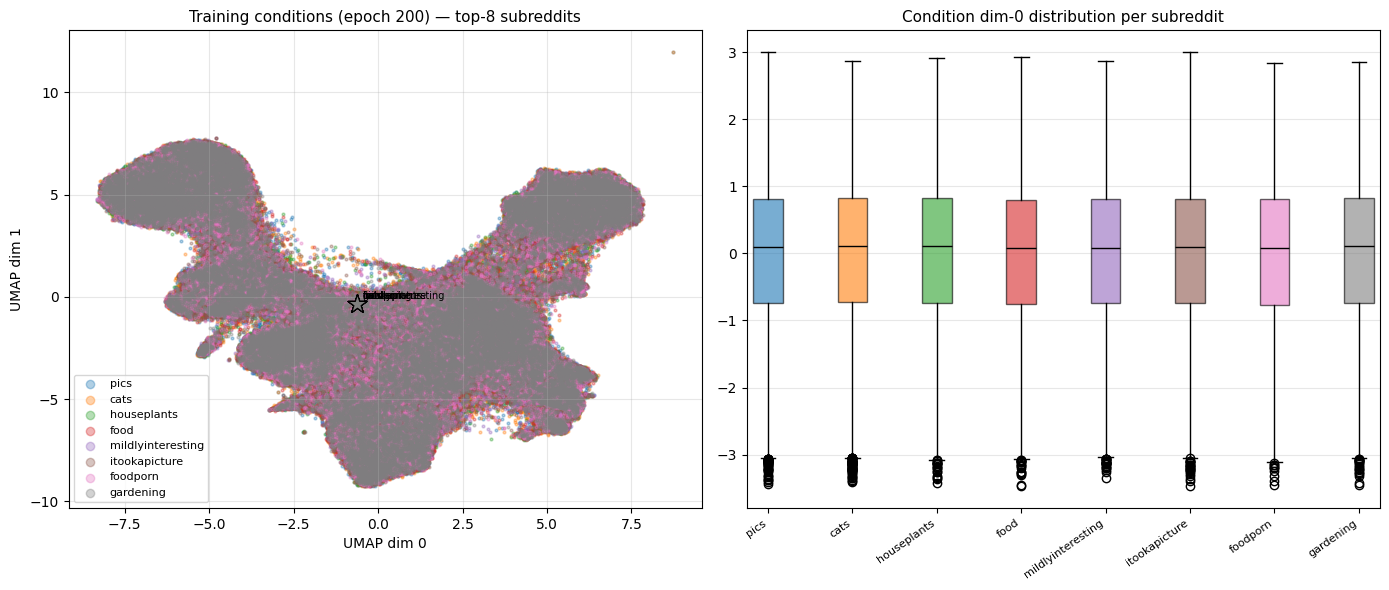

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
_train_cat_np = train_cat_idx.numpy()

# "other" samples in grey (plot first so top categories render on top)
_other_mask = _train_cat_np == N_CAT_SHOW
_pts_other = label_emb_2d[_other_mask][:5000]   # subsample for speed
ax.scatter(_pts_other[:, 0], _pts_other[:, 1], s=2, alpha=0.15,
           color="#AAAAAA", rasterized=True)

for c in range(N_CAT_SHOW):
    pts = label_emb_2d[_train_cat_np == c]
    ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.35, color=CAT_COLORS[c],
               label=CAT_NAMES[c], rasterized=True)
for c in range(N_CAT_SHOW):
    m = cat_means_2d[c]
    ax.scatter(m[0], m[1], s=200, color=CAT_COLORS[c], marker="*",
               edgecolors="black", linewidths=0.8, zorder=5)
    ax.annotate(CAT_NAMES[c], m, fontsize=7, xytext=(4, 4),
                textcoords="offset points")
ax.set_title(f"Training conditions (epoch {epoch}) — top-{N_CAT_SHOW} subreddits", fontsize=11)
ax.set_xlabel(f"{dim_label} 0"); ax.set_ylabel(f"{dim_label} 1")
ax.legend(markerscale=3, fontsize=8, loc="best")
ax.grid(True, alpha=0.3)

ax2 = axes[1]
step = 2
positions = [step * c for c in range(N_CAT_SHOW)]
_data = [label_emb_all[train_cat_idx == c, 0].numpy() for c in range(N_CAT_SHOW)]
bp = ax2.boxplot(_data, positions=positions, widths=0.7, patch_artist=True,
                 medianprops=dict(color="black"))
for patch, col in zip(bp["boxes"], CAT_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.6)
ax2.set_xticks(positions)
ax2.set_xticklabels(CAT_NAMES, rotation=35, ha="right", fontsize=8)
ax2.set_title("Condition dim-0 distribution per subreddit", fontsize=11)
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

---

## 2 — Directional Sweep

Sweeps a condition along a chosen direction; one line per top subreddit.

- **Left:** `Δ cos_sim(cond_query, GT_pair) vs CLIP baseline` (img-side) or
  `cos_sim(cond_txt, original_txt)` (txt-side).
- **Right:** `cos_sim(conditioned_query, GT_pair)` — alignment with GT. Peak = optimal position.

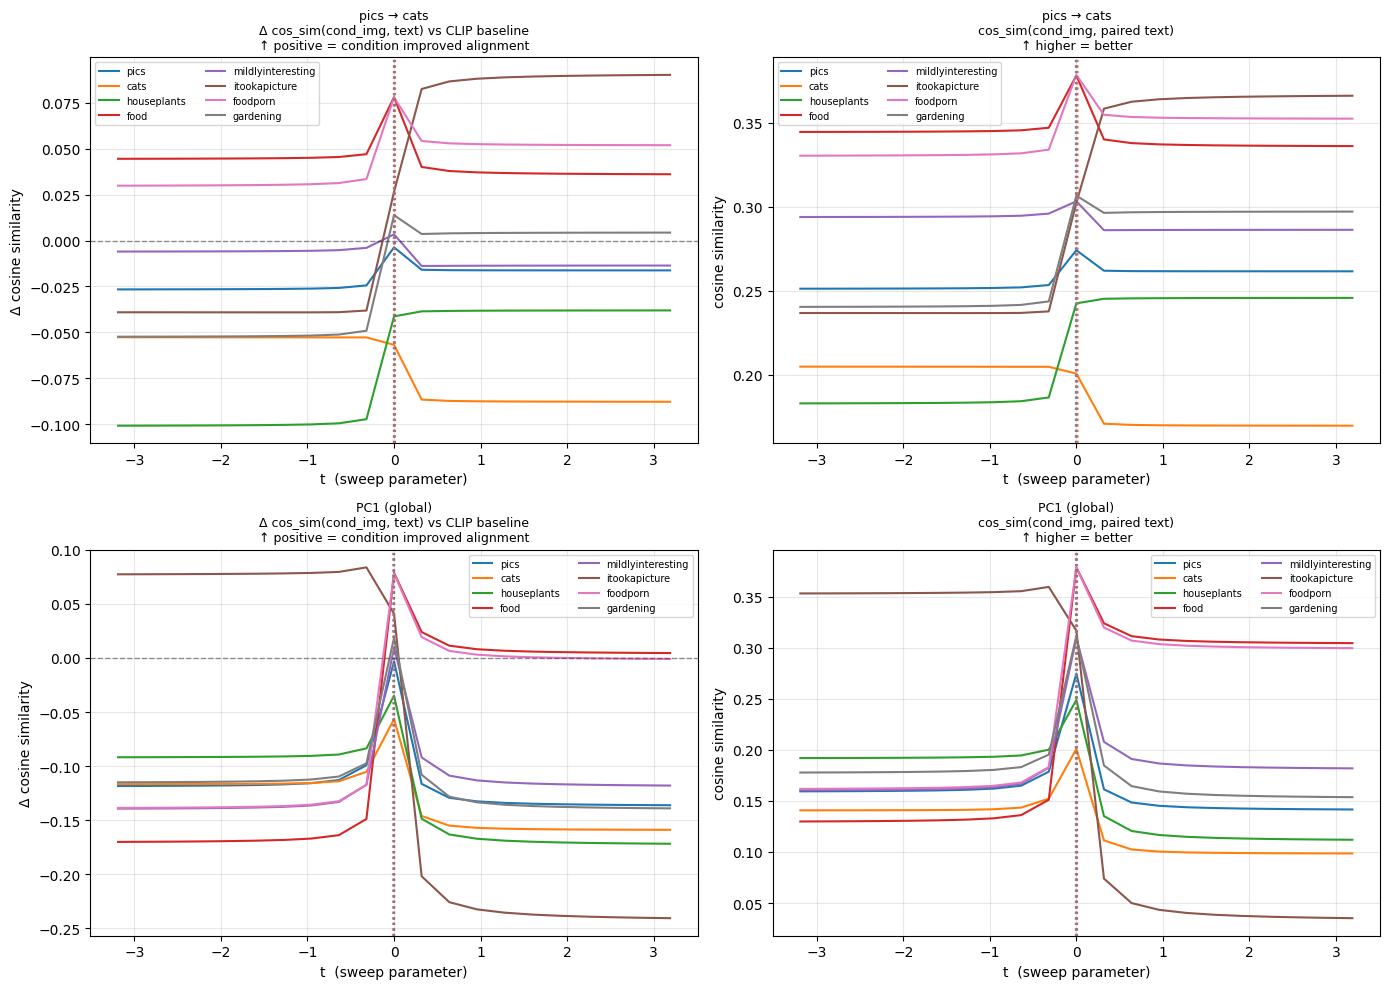

In [5]:
_d01 = cat_means[1] - cat_means[0]
dir_c0c1 = _d01 / (_d01.norm() + 1e-8)
_cov     = torch.cov(label_emb_all.T)
dir_pc1  = torch.linalg.eigh(_cov)[1][:, -1]

directions = {
    f"{CAT_NAMES[0]} → {CAT_NAMES[1]}": (dir_c0c1, cat_means[0]),
    "PC1 (global)": (dir_pc1, label_emb_all.mean(0)),
}
_span  = (label_emb_all @ dir_c0c1.unsqueeze(1)).squeeze().std().item() * 3
t_vals = torch.linspace(-_span, _span, N_SWEEP)

_orig_label = (
    "cos_sim(cond_txt, original_txt)\n↑ closer to 1.0 = less displacement"
    if COMBINE_SIDE == "txt"
    else "Δ cos_sim(cond_img, text) vs CLIP baseline\n↑ positive = condition improved alignment"
)
_align_label = (
    "cos_sim(cond_txt, GT image)\n↑ higher = better"
    if COMBINE_SIDE == "txt"
    else "cos_sim(cond_img, paired text)\n↑ higher = better"
)

fig, axes = plt.subplots(len(directions), 2, figsize=(14, 5 * len(directions)))
if len(directions) == 1:
    axes = axes[np.newaxis]

for row, (dir_name, (direction, origin)) in enumerate(directions.items()):
    results = {c: {"orig": [], "align": []} for c in range(N_CAT_SHOW)}
    for c in range(N_CAT_SHOW):
        q_idx     = get_query_indices(c, N_QUERIES)
        combine_q = get_combine_q(q_idx)
        pair_q    = get_pair_q(q_idx)
        orig_n    = F.normalize(combine_q, dim=-1)
        if COMBINE_SIDE == "img":
            _baseline = cos_sim(orig_n, pair_q)
        for tv in t_vals:
            ct = apply_condition(combine_q, origin + direction * tv)
            if COMBINE_SIDE == "txt":
                results[c]["orig"].append(cos_sim(ct, orig_n).mean().item())
            else:
                results[c]["orig"].append(
                    (cos_sim(ct, pair_q) - _baseline).mean().item()
                )
            results[c]["align"].append(cos_sim(ct, pair_q).mean().item())

    tv_np = t_vals.numpy()
    for col, key in enumerate(["orig", "align"]):
        ax = axes[row, col]
        for c in range(N_CAT_SHOW):
            ax.plot(tv_np, results[c][key], color=CAT_COLORS[c],
                    label=CAT_NAMES[c], lw=1.5)
        for c in range(N_CAT_SHOW):
            p = float((cat_means[c] - origin) @ direction)
            ax.axvline(p, color=CAT_COLORS[c], linestyle=":", alpha=0.6)
        ax.set_title(f"{dir_name}\n{_orig_label if col==0 else _align_label}", fontsize=9)
        ax.set_xlabel("t  (sweep parameter)")
        ax.set_ylabel("Δ cosine similarity" if (col==0 and COMBINE_SIDE=="img") else "cosine similarity")
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)
        if col == 0 and COMBINE_SIDE == "img":
            ax.axhline(0, color="black", linestyle="--", alpha=0.4, lw=1)

plt.tight_layout(); plt.show()

---

## 3 — Radial Sweep

Vary **magnitude** (3a) and **angle** (3b) of the condition independently.
Queries: category-0 samples (most common subreddit).

- 3a left: displacement or Δ alignment vs radius.
- 3a right: GT alignment vs radius — look for a peak.
- 3b: angular sweep at 0.5×, 1.0×, 1.5× median norm.

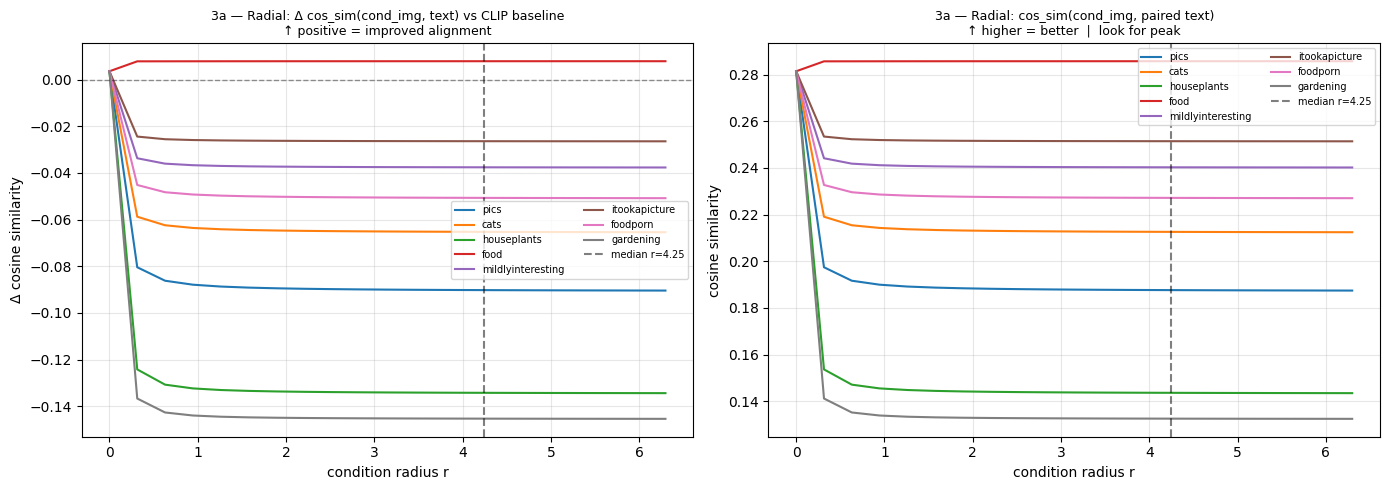

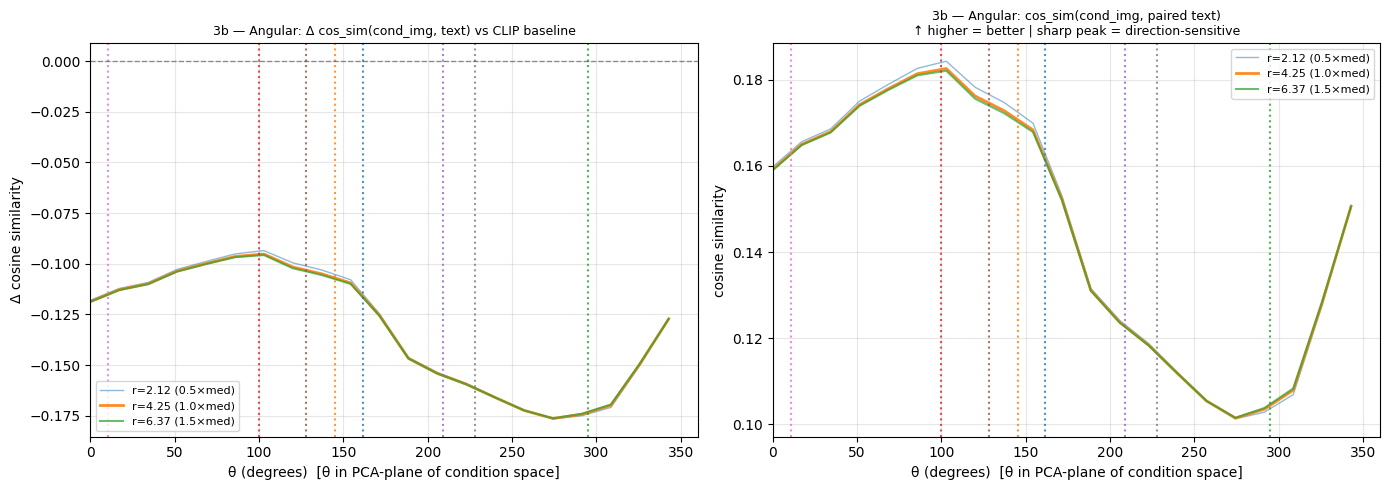

In [6]:
_q_idx    = get_query_indices(0, N_QUERIES)
_combine_q = get_combine_q(_q_idx)
_pair_q    = get_pair_q(_q_idx)
_orig_n    = F.normalize(_combine_q, dim=-1)
if COMBINE_SIDE == "img":
    _baseline_align_3 = cos_sim(_orig_n, _pair_q)

max_r = label_emb_all.norm(dim=-1).quantile(0.95).item()
r_vals = torch.linspace(0, max_r * 1.2, N_SWEEP)

_align_ylabel = (
    "cos_sim(cond_txt, GT image)" if COMBINE_SIDE == "txt"
    else "cos_sim(cond_img, paired text)"
)
_orig_title_3a = (
    "3a — Radial: cos_sim(cond_emb, original_emb)\n↑ closer to 1.0 = less displacement"
    if COMBINE_SIDE == "txt"
    else "3a — Radial: Δ cos_sim(cond_img, text) vs CLIP baseline\n↑ positive = improved alignment"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in range(N_CAT_SHOW):
    d = cat_means[c] / (cat_means[c].norm() + 1e-8)
    if COMBINE_SIDE == "txt":
        s_o = [cos_sim(apply_condition(_combine_q, d*r), _orig_n).mean().item() for r in r_vals]
    else:
        s_o = [(cos_sim(apply_condition(_combine_q, d*r), _pair_q) - _baseline_align_3).mean().item()
               for r in r_vals]
    s_i = [cos_sim(apply_condition(_combine_q, d*r), _pair_q).mean().item() for r in r_vals]
    axes[0].plot(r_vals.numpy(), s_o, color=CAT_COLORS[c], label=CAT_NAMES[c], lw=1.5)
    axes[1].plot(r_vals.numpy(), s_i, color=CAT_COLORS[c], label=CAT_NAMES[c], lw=1.5)
for ax in axes:
    ax.axvline(median_r, color="black", linestyle="--", alpha=0.5, label=f"median r={median_r:.2f}")
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3); ax.set_xlabel("condition radius r")
axes[0].set_ylabel("Δ cosine similarity" if COMBINE_SIDE=="img" else "cosine similarity")
axes[1].set_ylabel("cosine similarity")
axes[0].set_title(_orig_title_3a, fontsize=9)
axes[1].set_title(f"3a — Radial: {_align_ylabel}\n↑ higher = better  |  look for peak", fontsize=9)
if COMBINE_SIDE == "img":
    axes[0].axhline(0, color="black", linestyle="--", alpha=0.4, lw=1)
plt.tight_layout(); plt.show()

# ── 3b: angular sweep ──────────────────────────────────────────────────────
theta_vals = torch.linspace(0, 2 * np.pi, N_SWEEP + 1)[:-1]

if label_dim == 2:
    _b1 = torch.tensor([1.0, 0.0]); _b2 = torch.tensor([0.0, 1.0])
    sweep_label = "θ in raw 2D condition space"
else:
    _b1 = torch.tensor(_proj_for_means.components_[0], dtype=torch.float32)
    _b2 = torch.tensor(_proj_for_means.components_[1], dtype=torch.float32)
    sweep_label = "θ in PCA-plane of condition space"

_cat_angles = [
    float(np.degrees(np.arctan2(float(cat_means[c].float() @ _b2),
                                float(cat_means[c].float() @ _b1)))) % 360
    for c in range(N_CAT_SHOW)
]

def _make_cond(r, th):
    return _b1 * (r * float(th.cos())) + _b2 * (r * float(th.sin()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r_mult, lw, alpha in [(0.5, 1, 0.5), (1.0, 2, 0.9), (1.5, 1.5, 0.7)]:
    r = median_r * r_mult
    if COMBINE_SIDE == "txt":
        s_o = [cos_sim(apply_condition(_combine_q, _make_cond(r, th)), _orig_n).mean().item()
               for th in theta_vals]
    else:
        s_o = [(cos_sim(apply_condition(_combine_q, _make_cond(r, th)), _pair_q)
                - _baseline_align_3).mean().item() for th in theta_vals]
    s_i = [cos_sim(apply_condition(_combine_q, _make_cond(r, th)), _pair_q).mean().item()
           for th in theta_vals]
    td = theta_vals.numpy() * 180 / np.pi
    axes[0].plot(td, s_o, lw=lw, alpha=alpha, label=f"r={r:.2f} ({r_mult}×med)")
    axes[1].plot(td, s_i, lw=lw, alpha=alpha, label=f"r={r:.2f} ({r_mult}×med)")
for c in range(N_CAT_SHOW):
    for ax in axes:
        ax.axvline(_cat_angles[c], color=CAT_COLORS[c], linestyle=":", alpha=0.8, lw=1.5)
for ax in axes:
    ax.set_xlabel(f"θ (degrees)  [{sweep_label}]")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(0, 360)
axes[0].set_ylabel("Δ cosine similarity" if COMBINE_SIDE=="img" else "cosine similarity")
axes[1].set_ylabel("cosine similarity")
_orig_title_3b = (
    "3b — Angular: cos_sim(cond_emb, original_emb)\n↑ closer to 1.0 = less displacement"
    if COMBINE_SIDE == "txt"
    else "3b — Angular: Δ cos_sim(cond_img, text) vs CLIP baseline"
)
axes[0].set_title(_orig_title_3b, fontsize=9)
axes[1].set_title(f"3b — Angular: {_align_ylabel}\n↑ higher = better | sharp peak = direction-sensitive", fontsize=9)
if COMBINE_SIDE == "img":
    axes[0].axhline(0, color="black", linestyle="--", alpha=0.4, lw=1)
plt.tight_layout(); plt.show()

---

## 4 — Category-Mean Condition Matrix

N×N grid: rows = query category, columns = category whose mean condition is applied.

- **Left:** Δ alignment (img-side) or displacement (txt-side).
- **Middle:** Mean GT rank.
- **Right:** Δ rank vs CLIP baseline.

Precomputing conditioned image galleries...
  done.
CLIP baseline mean GT rank per category:
  pics                : 604.4
  cats                : 1320.8
  houseplants         : 973.5
  food                : 27.5
  mildlyinteresting   : 57.5
  itookapicture       : 28.9
  foodporn            : 120.8
  gardening           : 1089.8


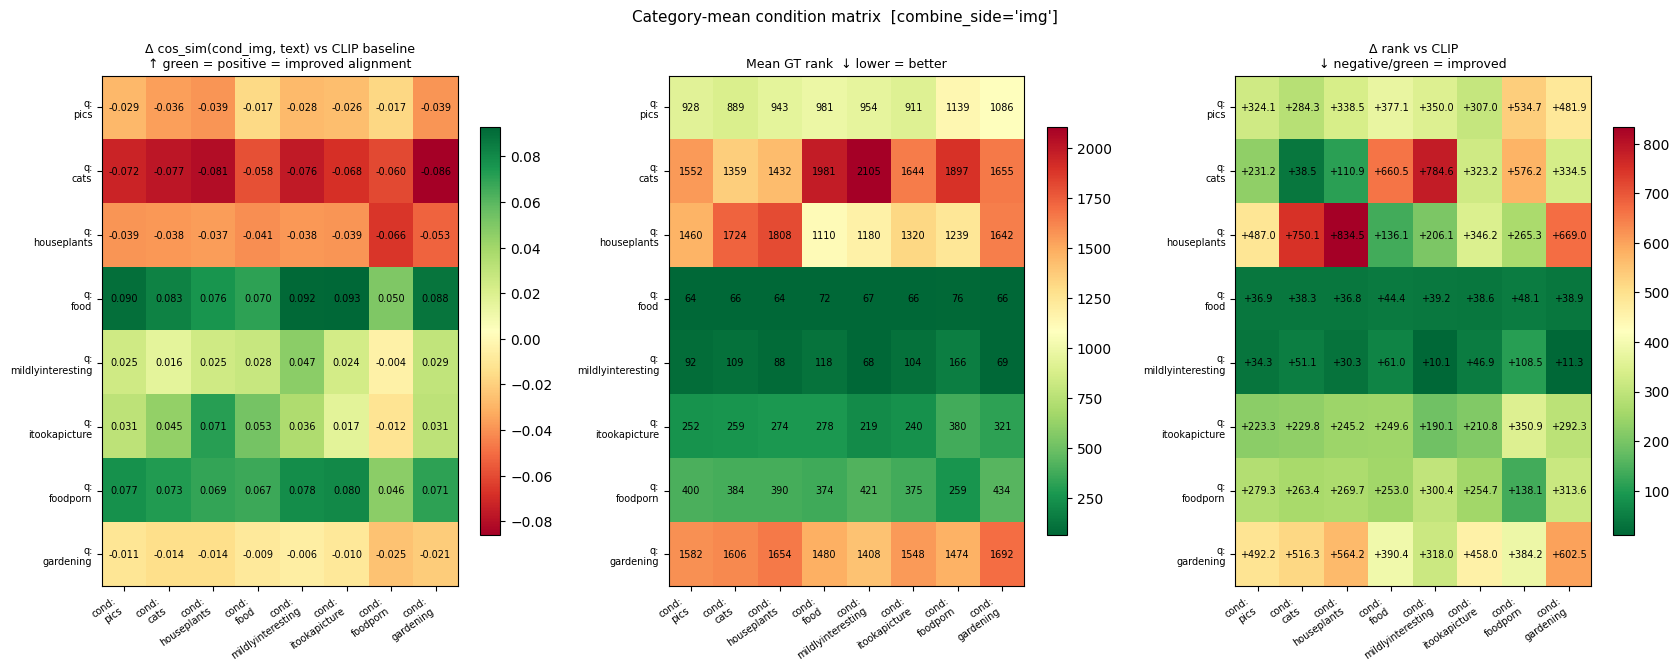

In [7]:
mat_cos  = np.zeros((N_CAT_SHOW, N_CAT_SHOW))
mat_rank = np.zeros((N_CAT_SHOW, N_CAT_SHOW))
clip_ranks = np.zeros(N_CAT_SHOW)

if COMBINE_SIDE == "img":
    print("Precomputing conditioned image galleries...")
    _cond_galleries = {ct: apply_condition(all_img_emb, cat_means[ct]) for ct in range(N_CAT_SHOW)}
    print("  done.")

for r_c in range(N_CAT_SHOW):
    q         = get_query_indices(r_c, N_MAT)
    combine_q = get_combine_q(q)
    orig_n    = F.normalize(combine_q, dim=-1)
    pair_q    = get_pair_q(q)

    if COMBINE_SIDE == "txt":
        clip_ranks[r_c] = mean_gt_rank(all_txt_emb[q], q)
    else:
        clip_ranks[r_c] = mean_gt_rank(all_img_emb, q)
        _base_align = cos_sim(orig_n, pair_q)

    for c_c in range(N_CAT_SHOW):
        if COMBINE_SIDE == "txt":
            ct = apply_condition(combine_q, cat_means[c_c])
            mat_rank[r_c, c_c] = mean_gt_rank(ct, q)
            mat_cos[r_c, c_c]  = cos_sim(ct, orig_n).mean().item()
        else:
            ct_gallery = _cond_galleries[c_c]
            ct         = ct_gallery[txt2img[q]]
            mat_rank[r_c, c_c] = mean_gt_rank(ct_gallery, q)
            mat_cos[r_c, c_c]  = (cos_sim(ct, pair_q) - _base_align).mean().item()

mat_delta = mat_rank - clip_ranks[:, np.newaxis]

_cos_title = (
    "cos_sim(cond_txt, original_txt)\n↑ green = close to 1.0 = small displacement"
    if COMBINE_SIDE == "txt"
    else "Δ cos_sim(cond_img, text) vs CLIP baseline\n↑ green = positive = improved alignment"
)

fig, axes = plt.subplots(1, 3, figsize=(6 * N_CAT_SHOW / 4 + 5, N_CAT_SHOW * 0.6 + 2))
for ax, mat, title, cmap, fmt in [
    (axes[0], mat_cos,   _cos_title,                                         "RdYlGn",   ".3f"),
    (axes[1], mat_rank,  "Mean GT rank  ↓ lower = better",                  "RdYlGn_r", ".0f"),
    (axes[2], mat_delta, "Δ rank vs CLIP\n↓ negative/green = improved",    "RdYlGn_r", "+.1f"),
]:
    im = ax.imshow(mat, cmap=cmap, aspect="auto")
    ax.set_xticks(range(N_CAT_SHOW))
    ax.set_xticklabels([f"cond:\n{n}" for n in CAT_NAMES], fontsize=7, rotation=35, ha="right")
    ax.set_yticks(range(N_CAT_SHOW))
    ax.set_yticklabels([f"q:\n{n}" for n in CAT_NAMES], fontsize=7)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(N_CAT_SHOW):
        for j in range(N_CAT_SHOW):
            ax.text(j, i, f"{mat[i,j]:{fmt}}", ha="center", va="center", fontsize=7)

print("CLIP baseline mean GT rank per category:")
for c in range(N_CAT_SHOW):
    print(f"  {CAT_NAMES[c]:20s}: {clip_ranks[c]:.1f}")
fig.suptitle(f"Category-mean condition matrix  [combine_side={COMBINE_SIDE!r}]", fontsize=11)
plt.tight_layout(); plt.show()

---

## 5 — Per-Image Deep Dive

Single test image: its one caption (for a 1v1 dataset) and top-5 retrieved images under
CLIP baseline and each category-mean condition. **Green border = GT image.**

Change `QUERY_IMAGE_IDX` to explore different images.

In [ ]:
QUERY_IMAGE_IDX = 0

# For 1v1, img2txt[i] is a 1-element tensor
_tidxs = img2txt[QUERY_IMAGE_IDX].tolist()   # [tidx]  (list of length 1)
row_types = [test_cat_idx[t].item() for t in _tidxs]
row_tidxs = _tidxs

@torch.no_grad()
def topk_images(emb, k=N_RETRIEVE):
    return torch.topk(
        (F.normalize(emb.unsqueeze(0).to(DEVICE), dim=-1) @ img_n.to(DEVICE).T)
        .squeeze(0).cpu(), k
    ).indices.tolist()

if COMBINE_SIDE == "txt":
    col_labels = ["CLIP\nbaseline"] + [f"cond:\n{CAT_NAMES[c]}" for c in range(N_CAT_SHOW)]
    fig, axes = plt.subplots(
        len(row_tidxs) * N_RETRIEVE, N_CAT_SHOW + 1,
        figsize=(1.6 * (N_CAT_SHOW + 1), 1.4 * len(row_tidxs) * N_RETRIEVE + 0.8),
        squeeze=False,
    )
    for r, (rt, tidx) in enumerate(zip(row_types, row_tidxs)):
        txt_emb = all_txt_emb[tidx]
        cols = [topk_images(txt_emb)] + [
            topk_images(apply_condition(txt_emb.unsqueeze(0), cat_means[c]).squeeze(0))
            for c in range(N_CAT_SHOW)
        ]
        gt = txt2img[tidx].item()
        for col, top_k in enumerate(cols):
            for rank, iidx in enumerate(top_k):
                ax = axes[r * N_RETRIEVE + rank, col]
                try:
                    ax.imshow(Image.open(image_paths[iidx]).convert("RGB"))
                except Exception:
                    ax.text(0.5, 0.5, f"img{iidx}", ha="center", va="center",
                            transform=ax.transAxes, fontsize=6)
                if iidx == gt:
                    for sp in ax.spines.values():
                        sp.set_edgecolor("limegreen"); sp.set_linewidth(3)
                ax.set_xticks([]); ax.set_yticks([])
                if rank == 0:
                    ax.set_title(col_labels[col], fontsize=7, pad=2)
                if col == 0 and rank == 0:
                    cat_lbl = CAT_NAMES[rt] if rt < N_CAT_SHOW else "other"
                    ax.set_ylabel(cat_lbl, fontsize=7, rotation=0, ha="right",
                                  va="center", labelpad=55)
else:
    print("Precomputing conditioned galleries for deep dive (img-side)...")
    _dd_galleries = {c: apply_condition(all_img_emb, cat_means[c]) for c in range(N_CAT_SHOW)}
    print("  done.")

    @torch.no_grad()
    def topk_from_gallery(txt_emb_1d, gallery):
        gn = F.normalize(gallery.to(DEVICE), dim=-1)
        scores = (F.normalize(txt_emb_1d.unsqueeze(0).to(DEVICE), dim=-1) @ gn.T).squeeze(0).cpu()
        return torch.topk(scores, N_RETRIEVE).indices.tolist()

    col_labels = ["CLIP\nbaseline"] + [f"cond:\n{CAT_NAMES[c]}" for c in range(N_CAT_SHOW)]
    fig, axes = plt.subplots(
        len(row_tidxs) * N_RETRIEVE, N_CAT_SHOW + 1,
        figsize=(1.6 * (N_CAT_SHOW + 1), 1.4 * len(row_tidxs) * N_RETRIEVE + 0.8),
        squeeze=False,
    )
    for r, (rt, tidx) in enumerate(zip(row_types, row_tidxs)):
        txt_emb = all_txt_emb[tidx]
        gt = txt2img[tidx].item()
        cols = [topk_images(txt_emb)] + [topk_from_gallery(txt_emb, _dd_galleries[c])
                                          for c in range(N_CAT_SHOW)]
        for col, top_k in enumerate(cols):
            for rank, iidx in enumerate(top_k):
                ax = axes[r * N_RETRIEVE + rank, col]
                try:
                    ax.imshow(Image.open(image_paths[iidx]).convert("RGB"))
                except Exception:
                    ax.text(0.5, 0.5, f"img{iidx}", ha="center", va="center",
                            transform=ax.transAxes, fontsize=6)
                if iidx == gt:
                    for sp in ax.spines.values():
                        sp.set_edgecolor("limegreen"); sp.set_linewidth(3)
                ax.set_xticks([]); ax.set_yticks([])
                if rank == 0:
                    ax.set_title(col_labels[col], fontsize=7, pad=2)
                if col == 0 and rank == 0:
                    cat_lbl = CAT_NAMES[rt] if rt < N_CAT_SHOW else "other"
                    ax.set_ylabel(cat_lbl, fontsize=7, rotation=0, ha="right",
                                  va="center", labelpad=55)

fig.suptitle(
    f"Image {QUERY_IMAGE_IDX}  [epoch {epoch}]  —  green = GT  [combine_side={COMBINE_SIDE!r}]",
    fontsize=9, y=1.002,
)
plt.tight_layout(); plt.show()

### 5b — PCA of Embeddings in CLIP Space

Original embedding → conditioned versions (one per category-mean) → GT anchor.

- **txt-side:** ○=original text, ▲=conditioned text, ■=GT image.
- **img-side:** ○=original image, ▲=conditioned image, ◆=GT text.

In [ ]:
from sklearn.decomposition import PCA

if COMBINE_SIDE == "txt":
    embs, meta = [], []
    for rt, tidx in zip(row_types, row_tidxs):
        embs.append(F.normalize(all_txt_emb[tidx], dim=-1).numpy())
        meta.append((rt, "orig"))
        for c in range(N_CAT_SHOW):
            ct = apply_condition(all_txt_emb[tidx].unsqueeze(0), cat_means[c]).squeeze(0)
            embs.append(F.normalize(ct, dim=-1).numpy())
            meta.append((rt, CAT_NAMES[c]))
    embs.append(img_n[QUERY_IMAGE_IDX].numpy())
    meta.append((-1, "image"))
    cond_title_detail = "○=orig txt  ▲=cond txt  ■=GT image"
else:
    _qimg = all_img_emb[QUERY_IMAGE_IDX]
    embs, meta = [], []
    embs.append(F.normalize(_qimg, dim=-1).numpy()); meta.append((-2, "orig_img"))
    for c in range(N_CAT_SHOW):
        ct = apply_condition(_qimg.unsqueeze(0), cat_means[c]).squeeze(0)
        embs.append(F.normalize(ct, dim=-1).numpy()); meta.append((-1, CAT_NAMES[c]))
    for rt, tidx in zip(row_types, row_tidxs):
        embs.append(F.normalize(all_txt_emb[tidx], dim=-1).numpy())
        meta.append((rt, "gt_text"))
    cond_title_detail = "○=orig img  ▲=cond img  ◆=GT text"

pca_model = PCA(n_components=2).fit(np.array(embs))
coords = pca_model.transform(np.array(embs))

fig, ax = plt.subplots(figsize=(9, 7))

if COMBINE_SIDE == "txt":
    orig_coords = {rt: coords[i] for i, (rt, k) in enumerate(meta) if k == "orig" and rt >= 0}
    for coord, (rt, kind) in zip(coords, meta):
        if rt == -1:
            ax.scatter(*coord, s=250, marker="s", color="black", zorder=6)
            ax.annotate("GT image", coord, fontsize=8, xytext=(4,4), textcoords="offset points")
        elif kind == "orig":
            c_col = CAT_COLORS[rt] if rt < N_CAT_SHOW else "#AAAAAA"
            ax.scatter(*coord, s=120, marker="o", color=c_col, zorder=5,
                       label=f"{CAT_NAMES[rt] if rt < N_CAT_SHOW else 'other'} (orig)")
            ax.annotate("", xy=coord, xytext=coord)
        else:
            if rt < N_CAT_SHOW:
                ax.scatter(*coord, s=60, marker="^", color=CAT_COLORS[rt], alpha=0.6, zorder=3)
                ax.annotate("", xy=coord, xytext=orig_coords.get(rt, coord),
                            arrowprops=dict(arrowstyle="->", color=CAT_COLORS[rt], alpha=0.5, lw=0.8))
else:
    _orig_coord = coords[0]
    ax.scatter(*_orig_coord, s=200, marker="o", color="black", zorder=6, label="orig image")
    ax.annotate("orig img", _orig_coord, fontsize=8, xytext=(4,4), textcoords="offset points")
    for coord, (rt, kind) in zip(coords, meta):
        if kind in CAT_NAMES:
            c = CAT_NAMES.index(kind)
            ax.scatter(*coord, s=100, marker="^", color=CAT_COLORS[c], zorder=5, label=f"cond:{kind}")
            ax.annotate("", xy=coord, xytext=_orig_coord,
                        arrowprops=dict(arrowstyle="->", color=CAT_COLORS[c], alpha=0.7, lw=1.5))
            ax.annotate(kind, coord, fontsize=7, color=CAT_COLORS[c], xytext=(4,4),
                        textcoords="offset points")
        elif kind == "gt_text":
            col = CAT_COLORS[rt] if rt < N_CAT_SHOW else "#AAAAAA"
            ax.scatter(*coord, s=80, marker="D", color=col, alpha=0.8, zorder=4)
    ax.scatter([], [], s=80, marker="D", color="grey", alpha=0.8, label="GT texts")

handles, lbls = ax.get_legend_handles_labels()
seen = set(); uh, ul = [], []
for h, l in zip(handles, lbls):
    if l not in seen:
        seen.add(l); uh.append(h); ul.append(l)
ax.legend(uh, ul, fontsize=7, ncol=2)
ax.set_title(
    f"PCA — image {QUERY_IMAGE_IDX}  [combine_side={COMBINE_SIDE!r}]\n{cond_title_detail}",
    fontsize=10,
)
ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]*100:.1f}%)")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# ── 5c: Before / After similarity for QUERY_IMAGE_IDX ────────────────────────
n_caps = len(row_tidxs)
sims5c = np.zeros((n_caps, N_CAT_SHOW + 1))  # [caption, 0=CLIP, 1..N=cat means]

with torch.no_grad():
    for r, (rt, tidx) in enumerate(zip(row_types, row_tidxs)):
        if COMBINE_SIDE == "txt":
            q_emb   = all_txt_emb[tidx]
            gt_n    = img_n[txt2img[tidx]]
            sims5c[r, 0] = cos_sim(F.normalize(q_emb, dim=-1).unsqueeze(0), gt_n.unsqueeze(0)).item()
            for c in range(N_CAT_SHOW):
                ct = apply_condition(q_emb.unsqueeze(0), cat_means[c]).squeeze(0)
                sims5c[r, c+1] = cos_sim(F.normalize(ct, dim=-1).unsqueeze(0), gt_n.unsqueeze(0)).item()
        else:
            q_emb   = all_img_emb[QUERY_IMAGE_IDX]
            gt_n    = txt_n[tidx]
            sims5c[r, 0] = cos_sim(F.normalize(q_emb, dim=-1).unsqueeze(0), gt_n.unsqueeze(0)).item()
            for c in range(N_CAT_SHOW):
                ct = apply_condition(q_emb.unsqueeze(0), cat_means[c]).squeeze(0)
                sims5c[r, c+1] = cos_sim(F.normalize(ct, dim=-1).unsqueeze(0), gt_n.unsqueeze(0)).item()

_col_labels5c = ["CLIP\nbase"] + [f"cond:\n{CAT_NAMES[c]}" for c in range(N_CAT_SHOW)]
_bar_colors5c = ["#AAAAAA"] + list(CAT_COLORS[:N_CAT_SHOW])
_sim_ylabel = ("cos_sim(cond_txt, GT image)" if COMBINE_SIDE=="txt"
               else "cos_sim(cond_img, paired text)")

width = 0.7 / max(n_caps, 1)
x_abs = np.arange(N_CAT_SHOW + 1)
x_dlt = np.arange(N_CAT_SHOW)

fig, axes = plt.subplots(1, 2, figsize=(max(12, N_CAT_SHOW * 1.5 + 4), 4))
ax, ax2 = axes

for r, (rt, tidx) in enumerate(zip(row_types, row_tidxs)):
    offset = (r - n_caps / 2 + 0.5) * width
    cat_lbl = CAT_NAMES[rt] if rt < N_CAT_SHOW else "other"
    c_col   = CAT_COLORS[rt] if rt < N_CAT_SHOW else "#AAAAAA"
    ax.bar(x_abs + offset, sims5c[r], width, color=c_col, alpha=0.8,
           edgecolor="black", linewidth=0.4, label=cat_lbl)
    delta = sims5c[r, 1:] - sims5c[r, 0]
    ax2.bar(x_dlt + offset, delta, width, color=c_col, alpha=0.8,
            edgecolor="black", linewidth=0.4, label=cat_lbl)

ax.set_xticks(x_abs); ax.set_xticklabels(_col_labels5c, fontsize=8)
ax.set_ylabel(_sim_ylabel)
ax.set_title(f"5c — Before/after similarity  [image {QUERY_IMAGE_IDX}, {COMBINE_SIDE}-side]\n↑ higher = closer to GT", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")

ax2.axhline(0, color="black", lw=1.2, ls="--", alpha=0.6)
ax2.set_xticks(x_dlt); ax2.set_xticklabels([f"cond:\n{CAT_NAMES[c]}" for c in range(N_CAT_SHOW)], fontsize=8)
ax2.set_ylabel(f"Δ similarity vs CLIP baseline")
ax2.set_title(f"5c — Δ similarity vs CLIP  [image {QUERY_IMAGE_IDX}, {COMBINE_SIDE}-side]\n↑ positive = improved", fontsize=10)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"{'Caption':20s}  {'CLIP':>8}", end="")
for c in range(N_CAT_SHOW): print(f"  {CAT_NAMES[c]:>12}", end="")
print(); print("-" * (30 + 14*N_CAT_SHOW))
for r, (rt, tidx) in enumerate(zip(row_types, row_tidxs)):
    cat_lbl = CAT_NAMES[rt] if rt < N_CAT_SHOW else "other"
    print(f"{cat_lbl:20s}  {sims5c[r,0]:8.4f}", end="")
    for c in range(N_CAT_SHOW):
        d = sims5c[r,c+1] - sims5c[r,0]
        print(f"  {sims5c[r,c+1]:6.4f}({'+'if d>=0 else ''}{d:.4f})", end="")
    print()

---

## 6 — CLIP Text-Image Gap by Category

Raw CLIP text-image cosine similarity and retrieval rank distributions per subreddit,
before any conditioning. Shows baseline alignment difficulty by category.

In [ ]:
clip_sims_by_cat  = {}
clip_ranks_by_cat = {}

for c in range(N_CAT_SHOW):
    q_idx = get_query_indices(c, n_txt)
    t_q   = txt_n[q_idx]
    i_q   = img_n[txt2img[q_idx]]
    clip_sims_by_cat[c] = F.cosine_similarity(t_q, i_q, dim=-1).numpy()
    scores = t_q @ img_n.T
    clip_ranks_by_cat[c] = np.array([
        (scores[b] > scores[b, txt2img[q_idx[b]].item()]).sum().item() + 1
        for b in range(len(q_idx))
    ])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in range(N_CAT_SHOW):
    d = clip_sims_by_cat[c]
    axes[0].hist(d, bins=30, alpha=0.5, color=CAT_COLORS[c],
                 label=f"{CAT_NAMES[c]} (μ={d.mean():.3f})", density=True)
    axes[0].axvline(d.mean(), color=CAT_COLORS[c], linestyle="--", lw=1.5)
    r = clip_ranks_by_cat[c]
    axes[1].hist(r, bins=30, alpha=0.5, color=CAT_COLORS[c],
                 label=f"{CAT_NAMES[c]} (med={np.median(r):.0f})", density=True)
    axes[1].axvline(np.median(r), color=CAT_COLORS[c], linestyle="--", lw=1.5)

axes[0].set_xlabel("cos_sim(text, paired image) — raw CLIP space")
axes[0].set_ylabel("density"); axes[0].set_title("CLIP text-image similarity by subreddit")
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("GT image rank (raw CLIP, no conditioning)  ↓ lower = better")
axes[1].set_ylabel("density"); axes[1].set_title("CLIP retrieval rank distribution by subreddit")
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'Category':20s}  {'N':>5}  {'μ cos':>8}  {'med rank':>9}  {'R@1%':>7}  {'R@5%':>7}")
for c in range(N_CAT_SHOW):
    cs = clip_sims_by_cat[c]; rk = clip_ranks_by_cat[c]
    print(f"{CAT_NAMES[c]:20s}  {len(cs):>5}  {cs.mean():8.4f}  {np.median(rk):9.0f}  "
          f"{(rk<=1).mean()*100:7.1f}  {(rk<=5).mean()*100:7.1f}")

---

## 7 — Zero-Condition Ablation

How much of the benefit comes from the combiner's weights (zero condition) vs the condition
direction? Columns: CLIP baseline, zero cond, random dir, category-mean conditions, best rep.
Rows: top subreddit categories.

In [ ]:
zero_cond   = torch.zeros(label_dim)
random_cond = torch.randn(label_dim)
random_cond = random_cond / random_cond.norm() * median_r
best_rep_idx = int(representatives.norm(dim=-1).argmin())

ablation_conditions = {"CLIP (no combiner)": None, "zero cond": zero_cond,
                       "random dir": random_cond}
for c in range(N_CAT_SHOW):
    ablation_conditions[f"cond: {CAT_NAMES[c]}"] = cat_means[c]
ablation_conditions[f"rep {best_rep_idx}"] = representatives[best_rep_idx]

rank_table = np.zeros((N_CAT_SHOW, len(ablation_conditions)))

if COMBINE_SIDE == "img":
    print("Precomputing galleries for ablation...")
    _abl_galleries = {label: apply_condition(all_img_emb, cond)
                      for label, cond in ablation_conditions.items() if cond is not None}
    print("  done.")

for r_c in range(N_CAT_SHOW):
    q_idx = get_query_indices(r_c, N_MAT)
    clip_r = (mean_gt_rank(all_txt_emb[q_idx], q_idx) if COMBINE_SIDE == "txt"
              else mean_gt_rank(all_img_emb, q_idx))
    for c_idx, (label, cond) in enumerate(ablation_conditions.items()):
        if cond is None:
            rank_table[r_c, c_idx] = clip_r
        elif COMBINE_SIDE == "txt":
            ct = apply_condition(get_combine_q(q_idx), cond)
            rank_table[r_c, c_idx] = mean_gt_rank(ct, q_idx)
        else:
            rank_table[r_c, c_idx] = mean_gt_rank(_abl_galleries[label], q_idx)

clip_col    = rank_table[:, 0]
delta_table = rank_table - clip_col[:, np.newaxis]
cond_labels = list(ablation_conditions.keys())

fig, axes = plt.subplots(1, 2, figsize=(max(14, len(cond_labels)*1.8), N_CAT_SHOW*0.6+2))
for ax, mat, title, cmap, fmt in [
    (axes[0], rank_table,  "Mean GT rank  ↓ lower = better", "RdYlGn_r", ".0f"),
    (axes[1], delta_table, "Δ rank vs CLIP  ↓ negative/green = better", "RdYlGn_r", "+.0f"),
]:
    im = ax.imshow(mat, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(cond_labels)))
    ax.set_xticklabels(cond_labels, fontsize=7, rotation=35, ha="right")
    ax.set_yticks(range(N_CAT_SHOW))
    ax.set_yticklabels([f"q: {n}" for n in CAT_NAMES], fontsize=8)
    ax.set_title(title, fontsize=10); plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(N_CAT_SHOW):
        for j in range(len(cond_labels)):
            ax.text(j, i, f"{mat[i,j]:{fmt}}", ha="center", va="center", fontsize=7)
fig.suptitle(f"Zero-condition ablation  [combine_side={COMBINE_SIDE!r}]", fontsize=11)
plt.tight_layout(); plt.show()

---

## 8 — Per-Representative × Per-Category Rank Heatmap

All K representative conditions applied to queries of each subreddit category.
Green (negative Δ) = improvement over CLIP baseline.

In [ ]:
rep_cat_delta = np.zeros((K, N_CAT_SHOW))
type_q_idx = {c: get_query_indices(c, 706) for c in range(N_CAT_SHOW)}

if COMBINE_SIDE == "txt":
    clip_r_per_cat = {c: mean_gt_rank(all_txt_emb[type_q_idx[c]], type_q_idx[c])
                      for c in range(N_CAT_SHOW)}
else:
    clip_r_per_cat = {c: mean_gt_rank(all_img_emb, type_q_idx[c])
                      for c in range(N_CAT_SHOW)}

with torch.no_grad():
    for k in range(K):
        if COMBINE_SIDE == "txt":
            for c in range(N_CAT_SHOW):
                q = type_q_idx[c]
                cond = representatives[k].unsqueeze(0).expand(len(q), -1)
                ct = combiner(all_txt_emb[q].to(DEVICE), None, cond.to(DEVICE)).cpu()
                rep_cat_delta[k, c] = mean_gt_rank(ct, q) - clip_r_per_cat[c]
        else:
            cond = representatives[k].unsqueeze(0).expand(all_img_emb.shape[0], -1)
            ct_gallery = combiner(all_img_emb.to(DEVICE), None, cond.to(DEVICE)).cpu()
            for c in range(N_CAT_SHOW):
                rep_cat_delta[k, c] = mean_gt_rank(ct_gallery, type_q_idx[c]) - clip_r_per_cat[c]
        print(f"  rep {k+1}/{K}", end="\r")
print()

fig, axes = plt.subplots(1, 2, figsize=(N_CAT_SHOW * 1.5 + 4, max(6, K * 0.35 + 2)))
im = axes[0].imshow(rep_cat_delta, cmap="RdYlGn_r", aspect="auto")
axes[0].set_xticks(range(N_CAT_SHOW))
axes[0].set_xticklabels(
    [f"{CAT_NAMES[c]}\n(CLIP={clip_r_per_cat[c]:.0f})" for c in range(N_CAT_SHOW)],
    fontsize=8, rotation=35, ha="right",
)
axes[0].set_yticks(range(K))
axes[0].set_yticklabels([f"rep{k}" for k in range(K)], fontsize=7)
axes[0].set_title(f"Δ rank vs CLIP per rep × category  [{COMBINE_SIDE}-side]\n↓ green = better", fontsize=9)
plt.colorbar(im, ax=axes[0], shrink=0.8)
for i in range(K):
    for j in range(N_CAT_SHOW):
        axes[0].text(j, i, f"{rep_cat_delta[i,j]:+.0f}", ha="center", va="center", fontsize=6)

ranges = rep_cat_delta.max(0) - rep_cat_delta.min(0)
best_per_cat  = rep_cat_delta.argmin(0)
worst_per_cat = rep_cat_delta.argmax(0)
axes[1].bar(range(N_CAT_SHOW), ranges, color=list(CAT_COLORS[:N_CAT_SHOW]), alpha=0.8, edgecolor="black")
for i in range(N_CAT_SHOW):
    axes[1].text(i, ranges[i] + 0.2, f"range={ranges[i]:.1f}\nbest=rep{best_per_cat[i]}",
                 ha="center", va="bottom", fontsize=7)
axes[1].set_xticks(range(N_CAT_SHOW)); axes[1].set_xticklabels(CAT_NAMES, fontsize=8, rotation=35, ha="right")
axes[1].set_ylabel("rank range across reps")
axes[1].set_title("Condition sensitivity per subreddit\n↑ taller = specific condition matters more", fontsize=10)
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

---

## 9 — Epoch Evolution of Category-Mean Trajectories

Tracks each subreddit's mean condition position, norm, and inter-category distance over training.

In [ ]:
all_snaps_ev = []
for f in epoch_files:
    s = torch.load(f, map_location="cpu", weights_only=False)
    _tci = s.get("train_sample_types")
    if _tci is None:
        if 'train_cat_idx' not in dir():
            import json as _json
            _ta = _json.load(open(TRAIN_JSON_PATH))
            _tci = torch.tensor([_cat_map.get(_sub(a["image"]), N_CAT_SHOW) for a in _ta], dtype=torch.long)
        else:
            _tci = train_cat_idx
    le = s["label_embeddings_all"]
    means_raw = {c: le[_tci == c].mean(0).numpy() for c in range(N_CAT_SHOW)}
    if _proj_for_means is None:
        means_2d_ev = {c: means_raw[c] for c in range(N_CAT_SHOW)}
    else:
        means_2d_ev = {c: _proj_for_means.transform(means_raw[c].reshape(1,-1))[0]
                       for c in range(N_CAT_SHOW)}
    norms = {c: float(le[_tci == c].norm(dim=-1).mean()) for c in range(N_CAT_SHOW)}
    inter = {(i,j): float(np.linalg.norm(means_raw[i]-means_raw[j]))
             for i in range(N_CAT_SHOW) for j in range(i+1, N_CAT_SHOW)}
    all_snaps_ev.append({"epoch": s["epoch"], "means_2d": means_2d_ev, "norms": norms, "inter": inter})

epochs_seq = [s["epoch"] for s in all_snaps_ev]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
for c in range(N_CAT_SHOW):
    xs = [s["means_2d"][c][0] for s in all_snaps_ev]
    ys = [s["means_2d"][c][1] for s in all_snaps_ev]
    ax.plot(xs, ys, color=CAT_COLORS[c], lw=1.5, alpha=0.7)
    ax.scatter(xs[0], ys[0], marker="o", s=60, color=CAT_COLORS[c], zorder=5)
    ax.scatter(xs[-1], ys[-1], marker="*", s=200, color=CAT_COLORS[c],
               edgecolors="black", linewidths=0.8, zorder=6, label=CAT_NAMES[c])
ax.set_title("Category-mean trajectories  ○=start  ★=final", fontsize=10)
ax.set_xlabel(f"{dim_label} 0"); ax.set_ylabel(f"{dim_label} 1")
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for c in range(N_CAT_SHOW):
    ax2.plot(epochs_seq, [s["norms"][c] for s in all_snaps_ev],
             color=CAT_COLORS[c], lw=2, label=CAT_NAMES[c])
ax2.set_title("‖category-mean‖ over training\n↑ higher = stronger average directional signal", fontsize=10)
ax2.set_xlabel("epoch"); ax2.set_ylabel("mean condition norm")
ax2.legend(fontsize=7, ncol=2); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
# Show top-4 inter-category pairs for readability
_top_pairs = sorted(all_snaps_ev[-1]["inter"].keys(),
                    key=lambda k: -all_snaps_ev[-1]["inter"][k])[:min(6, N_CAT_SHOW)]
for (i,j) in _top_pairs:
    ax3.plot(epochs_seq, [s["inter"][(i,j)] for s in all_snaps_ev], lw=1.5,
             label=f"{CAT_NAMES[i][:8]}–{CAT_NAMES[j][:8]}")
ax3.set_title("Inter-category mean distances over training\n↑ higher = categories more separated", fontsize=10)
ax3.set_xlabel("epoch"); ax3.set_ylabel("‖μ_i − μ_j‖")
ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## 10 — Condition Category Separability

k-NN classification accuracy, inter/intra-category pairwise distances, and image-identity
clustering — measuring how well conditions encode subreddit category.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from scipy import stats as scipy_stats

# Subsample for tractability
_rng = np.random.default_rng(42)
_mask = train_cat_idx < N_CAT_SHOW  # top-N only
X_all = label_emb_all[_mask].numpy()
y_all = train_cat_idx[_mask].numpy()
_sub_idx = _rng.choice(len(X_all), size=min(10000, len(X_all)), replace=False)
X, y = X_all[_sub_idx], y_all[_sub_idx]

k_vals = [1, 3, 5, 11, 21]
knn_scores = {}
for k in k_vals:
    sc = cross_val_score(KNeighborsClassifier(k), X, y, cv=5, scoring="accuracy")
    knn_scores[k] = (sc.mean(), sc.std())

_sub2 = _rng.choice(len(X), size=min(2000, len(X)), replace=False)
Xs, ys = X[_sub2], y[_sub2]
intra_d, inter_d = [], []
for i in range(len(Xs)):
    for j in range(i+1, len(Xs)):
        d = np.linalg.norm(Xs[i] - Xs[j])
        (intra_d if ys[i]==ys[j] else inter_d).append(d)
intra_d = np.array(intra_d); inter_d = np.array(inter_d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ks = list(knn_scores.keys())
ax.bar(range(len(ks)), [knn_scores[k][0] for k in ks],
       yerr=[knn_scores[k][1] for k in ks],
       color="steelblue", alpha=0.8, capsize=5, edgecolor="black")
ax.axhline(1/N_CAT_SHOW, color="red", linestyle="--", lw=1.5,
           label=f"random baseline ({100/N_CAT_SHOW:.0f}%)")
ax.set_xticks(range(len(ks))); ax.set_xticklabels([f"{k}-NN" for k in ks])
ax.set_ylabel("5-fold CV accuracy")
ax.set_title(f"Subreddit prediction from condition vector\n↑ higher = conditions encode subreddit", fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
for i,k in enumerate(ks):
    ax.text(i, knn_scores[k][0]+knn_scores[k][1]+0.003, f"{knn_scores[k][0]:.3f}",
            ha="center", fontsize=9)

ax2 = axes[1]
ax2.hist(intra_d, bins=60, alpha=0.6, color="#2196F3", density=True,
         label=f"intra-cat (μ={intra_d.mean():.3f})")
ax2.hist(inter_d, bins=60, alpha=0.6, color="#FF5722", density=True,
         label=f"inter-cat (μ={inter_d.mean():.3f})")
ax2.axvline(intra_d.mean(), color="#2196F3", ls="--", lw=1.5)
ax2.axvline(inter_d.mean(), color="#FF5722", ls="--", lw=1.5)
ax2.set_xlabel("pairwise condition distance  blue=same cat  red=different cat")
ax2.set_ylabel("density")
ax2.set_title("Inter vs intra-category pairwise distances", fontsize=10)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
_, pv = scipy_stats.ttest_ind(inter_d, intra_d)
ax2.text(0.98, 0.97, f"t-test p={pv:.2e}", transform=ax2.transAxes,
         ha="right", va="top", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout(); plt.show()

print(f"Inter/intra distance ratio: {inter_d.mean()/intra_d.mean():.4f}  (>1 = categories separated)")
print(f"t-test p-value: {pv:.2e}")
for k in k_vals:
    print(f"  {k}-NN accuracy: {knn_scores[k][0]:.4f} ± {knn_scores[k][1]:.4f}")